In [28]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

import networkx as nx
import numpy as np

def radial_layout_brockmann_helbing(G, root, weight='distance', angle_span=2*np.pi, scale=0.9):
    """
    Genera un layout radial estilo Brockmann & Helbing (2013).

    Parámetros:
    - G: grafo de NetworkX (no dirigido) con atributo 'distance' en aristas.
    - root: nodo raíz (en el centro).
    - weight: nombre del atributo de arista con la distancia.
    - angle_span: ángulo total para distribuir los nodos (2π por defecto).
    - scale: factor de escala para que los nodos no toquen el borde (0.9 por defecto).

    Retorna:
    - pos: dict {nodo: (x, y)} con coordenadas en el disco (normalizadas a [-1,1]).
    """
    # 1. Calcular capas BFS (profundidad topológica) y distancia más corta ponderada (Dijkstra)
    layers = {root: 0}
    queue = [root]

    # Capas mediante BFS (sin pesos) – se usan para agrupar y asignar ángulos
    for node in queue:
        for neighbor in G.neighbors(node):
            if neighbor not in layers:
                layers[neighbor] = layers[node] + 1
                queue.append(neighbor)

    # Distancias más cortas ponderadas desde la raíz usando Dijkstra
    shortest_dist = nx.single_source_dijkstra_path_length(G, root, weight=weight)
    
    # Para nodos no alcanzables (por si acaso) se les asigna una distancia infinita,
    # pero los ignoraremos en el layout.
    for node in G.nodes():
        if node not in layers:
            layers[node] = -1
        if node not in shortest_dist:
            shortest_dist[node] = float('inf')

    # 2. Agrupar nodos por capa (solo los alcanzables)
    nodes_by_layer = {}
    for node, layer in layers.items():
        if layer >= 0 and shortest_dist[node] != float('inf'):
            nodes_by_layer.setdefault(layer, []).append(node)

    # 3. Asignar radios (distancias radiales) normalizadas al intervalo [0, 1]
    #    usando las distancias más cortas ponderadas
    finite_dists = [d for d in shortest_dist.values() if d != float('inf')]
    max_dist = max(finite_dists) if finite_dists else 1.0
    if max_dist == 0:
        max_dist = 1.0

    radii = {}
    for node in G.nodes():
        if node == root:
            radii[node] = 0.0
        else:
            d = shortest_dist.get(node, float('inf'))
            if d == float('inf'):
                radii[node] = 0.0   # nodos no alcanzables se colocan en el centro (o se ignoran)
            else:
                radii[node] = (d / max_dist) * scale

    # 4. Asignar ángulos de forma uniforme dentro de cada capa
    pos = {}
    for layer, nodes in nodes_by_layer.items():
        if layer == 0:
            pos[root] = (0.0, 0.0)
            continue

        n = len(nodes)
        if n == 0:
            continue

        angles = np.linspace(0, angle_span, n, endpoint=False)

        for i, node in enumerate(nodes):
            r = radii[node]
            theta = angles[i]
            x = r * np.cos(theta)
            y = r * np.sin(theta)
            pos[node] = (x, y)

    return pos


import networkx as nx
import numpy as np

def radial_layout_brockmann_helbing_radial(G, root, weight='distance', angle_span=2*np.pi, scale=0.9):
    """
    Genera un layout radial estilo Brockmann & Helbing (2013) con 
    organización angular jerárquica (por sectores).

    Parámetros:
    - G: grafo de NetworkX (no dirigido) con atributo 'distance' en aristas.
    - root: nodo raíz (en el centro).
    - weight: nombre del atributo de arista con la distancia (para Dijkstra).
    - angle_span: ángulo total para distribuir los nodos (2π por defecto).
    - scale: factor de escala para que los nodos no toquen el borde (0.9 por defecto).

    Retorna:
    - pos: dict {nodo: (x, y)} con coordenadas en el disco (normalizadas a [-1,1]).
    """
    # 1. Construir el árbol BFS (capas y padres) para la organización angular
    layers = {root: 0}
    parent = {root: None}
    queue = [root]
    
    for node in queue:
        for neighbor in G.neighbors(node):
            if neighbor not in layers:
                layers[neighbor] = layers[node] + 1
                parent[neighbor] = node
                queue.append(neighbor)

    # 2. Distancias más cortas ponderadas (Dijkstra) para el RADIO
    shortest_dist = nx.single_source_dijkstra_path_length(G, root, weight=weight)
    for node in G.nodes():
        if node not in layers:
            layers[node] = -1
        if node not in shortest_dist:
            shortest_dist[node] = float('inf')

    # 3. Construir lista de hijos (dentro del árbol BFS)
    children = {node: [] for node in G.nodes()}
    for node, p in parent.items():
        if p is not None:
            children[p].append(node)

    # 4. Calcular el tamaño de cada subárbol (número de nodos que cuelgan de él)
    subtree_size = {node: 1 for node in G.nodes()}
    for node in reversed(queue):  # Orden inverso BFS
        for child in children[node]:
            subtree_size[node] += subtree_size[child]

    # 5. Asignar ángulos de forma jerárquica (por sectores)
    node_angle = {}  # Almacenará el ángulo final de cada nodo (en radianes)

    def allocate(node, start_angle, end_angle):
        """
        Asigna a 'node' el sector [start_angle, end_angle].
        El nodo se coloca en el ángulo medio de su sector.
        Sus hijos se reparten este sector proporcionalmente a su subárbol.
        """
        # El nodo se sitúa en el centro de su sector
        node_angle[node] = (start_angle + end_angle) / 2.0

        if not children[node]:
            return

        # Ordenamos los hijos de mayor a menor subárbol para que las ramas grandes
        # ocupen sectores más amplios y contiguos (mejora visual)
        child_list = sorted(children[node], key=lambda x: subtree_size[x], reverse=True)
        
        total_subtree = sum(subtree_size[child] for child in child_list)
        current_start = start_angle
        
        for child in child_list:
            # La fracción del sector que le corresponde a este hijo
            fraction = subtree_size[child] / total_subtree
            sector_size = (end_angle - start_angle) * fraction
            child_end = current_start + sector_size
            
            # Llamada recursiva para el hijo
            allocate(child, current_start, child_end)
            current_start = child_end

    # Iniciamos la asignación desde la raíz (que ocupa todo el círculo)
    allocate(root, 0, angle_span)

    # 6. Calcular radios (distancias radiales) usando las distancias de Dijkstra
    finite_dists = [d for d in shortest_dist.values() if d != float('inf')]
    max_dist = max(finite_dists) if finite_dists else 1.0
    if max_dist == 0:
        max_dist = 1.0

    radii = {}
    for node in G.nodes():
        if node == root:
            radii[node] = 0.0
        else:
            d = shortest_dist.get(node, float('inf'))
            if d == float('inf'):
                radii[node] = 0.0  # Nodos aislados se quedan en el centro (o puedes filtrarlos)
            else:
                radii[node] = (d / max_dist) * scale

    # 7. Generar las coordenadas finales (x, y)
    pos = {}
    for node in G.nodes():
        if node in node_angle and node in radii:
            r = radii[node]
            theta = node_angle[node]
            pos[node] = (r * np.cos(theta), r * np.sin(theta))
        else:
            pos[node] = (0.0, 0.0)  # Fallback para nodos no alcanzables

    return pos

In [2]:
import pipeline.data as data
import pipeline.hyperbolic as hyp

G, df, params = data.read_hyperbolic_data("generated-nets-2/s1h2-s=12345/s1h2-n=1000-k=20-g=2.1-b=2.1-s=12345.gen_coord", 
                                            "generated-nets-2/s1h2-s=12345/s1h2-n=1000-k=20-g=2.1-b=2.1-s=12345.edge",
                                            True)

coords = (
            df.set_index('Vertex')
            [['Disc.Radius', 'Inf.Theta']]
            .to_dict('index')
        )

for u, v in G.edges():
            
            r1 = coords[u]['Disc.Radius']
            t1 = coords[u]['Inf.Theta']

            r2 = coords[v]['Disc.Radius']
            t2 = coords[v]['Inf.Theta']

            d = hyp.hyperbolic_distance_og_thetas(r1, t1, r2, t2)

            G[u][v]['distance'] = d

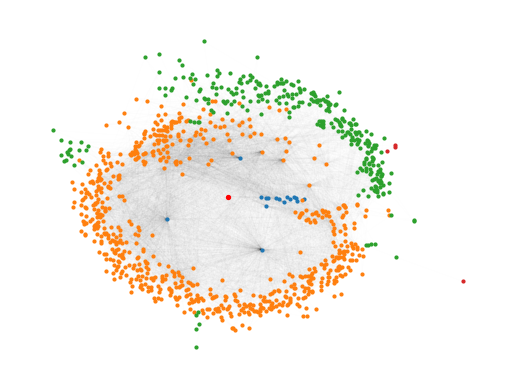

In [34]:
import matplotlib.pyplot as plt
import networkx as nx

# --- Parámetros iniciales ---
source = '271'
max_dist = 10  # Cambia este número para pintar hasta 1os, 2os, 3os... vecinos (ej: 3 para hasta 3er anillo)

# --- Posiciones y distancias ---
pos = radial_layout_brockmann_helbing_radial(G, source)

# Calcula la distancia mínima desde '875' a TODOS los nodos
distances = nx.single_source_shortest_path_length(G, source)

# Agrupa los nodos por su distancia (capas)
layers = {}
for node, dist in distances.items():
    if 0 < dist <= max_dist:  # Excluimos el nodo origen (dist=0)
        layers.setdefault(dist, []).append(node)

# --- Dibujar las aristas ---
# Dibujamos TODAS las aristas del grafo (o solo las de estos nodos) con color suave
# para dar contexto. Si quieres ver solo la estructura de estos nodos, usa:
# subgraph_nodes = [n for d in range(1, max_dist+1) for n in layers.get(d, [])]
# nx.draw_networkx_edges(G, pos, edgelist=G.edges(subgraph_nodes), alpha=0.3)
nx.draw_networkx_edges(G, pos, edge_color='#00000001')  # Opción global

# --- Dibujar los nodos por capas (cada capa un color) ---
for dist, nodelist in sorted(layers.items()):
    # Asignamos un color distinto a cada distancia usando una paleta
    color = plt.cm.tab10((dist-1) % 20)  # Recicla colores si hay más de 20 capas
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=nodelist,
        node_size=4,
        node_color=[color]  # Importante: pasar una lista de un solo color
    )

# --- Dibujar el nodo origen (875) con un color destacado ---
nx.draw_networkx_nodes(
    G, pos,
    nodelist=[source],
    node_size=8,          # Un poco más grande para que resalte
    node_color='red'
)

# Eliminar ejes y mostrar
plt.axis('off')
plt.show()